# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis

**Name:** Anusha Pittala  
**Course:** Advanced Big Data and Data Mining (MSCS-634-M50)  
**Semester:** Fall 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Data Collection

For this lab, I created a small retail sales dataset containing product, category, region, units sold, unit price, customer rating, and revenue information.

In [2]:
data = {
    'Date': [
        '2026-01-05', '2026-01-12', '2026-01-19', '2026-01-26',
        '2026-02-02', '2026-02-09', '2026-02-16', '2026-02-23',
        '2026-03-02', '2026-03-09', '2026-03-16', '2026-03-23',
        '2026-04-01', '2026-04-08', '2026-04-15', '2026-04-22',
        '2026-05-01', '2026-05-08', '2026-05-15', '2026-05-22'
    ],

    'Product': [
        'Laptop', 'Mouse', 'Keyboard', 'Monitor',
        'Laptop', 'Mouse', 'Keyboard', 'Monitor',
        'Laptop', 'Mouse', 'Keyboard', 'Monitor',
        'Laptop', 'Mouse', 'Keyboard', 'Monitor',
        'Laptop', 'Mouse', 'Keyboard', 'Monitor'
    ],

    'Category': [
        'Computers', 'Accessories', 'Accessories', 'Electronics',
        'Computers', 'Accessories', 'Accessories', 'Electronics',
        'Computers', 'Accessories', 'Accessories', 'Electronics',
        'Computers', 'Accessories', 'Accessories', 'Electronics',
        'Computers', 'Accessories', 'Accessories', 'Electronics'
    ],

    'Region': [
        'East', 'West', 'South', 'North',
        'East', 'West', None, 'North',
        'South', 'West', 'East', 'North',
        'East', None, 'South', 'West',
        'North', 'East', 'South', 'West'
    ],

    'Units_Sold': [
        12, 35, 28, 20,
        15, 42, 30, 18,
        17, 38, 25, 22,
        150, 40, 32, 19,
        14, 36, 27, 21
    ],

    'Unit_Price': [
        850, 25, 45, 220,
        900, 30, 50, 240,
        875, 28, 48, 230,
        920, 27, 52, 250,
        890, 29, 47, 235
    ],

    'Customer_Rating': [
        4.5, 4.0, 4.2, 3.9,
        4.6, np.nan, 4.1, 4.3,
        4.7, 3.8, 4.0, 4.2,
        4.5, 4.1, np.nan, 4.4,
        4.6, 3.9, 4.3, 4.2
    ]
}

df = pd.DataFrame(data)

df['Date'] = pd.to_datetime(df['Date'])

df['Revenue'] = df['Units_Sold'] * df['Unit_Price']

df.head()

,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
0,2026-01-05,Laptop,Computers,East,12,850,4.5,10200
1,2026-01-12,Mouse,Accessories,West,35,25,4.0,875
2,2026-01-19,Keyboard,Accessories,South,28,45,4.2,1260
3,2026-01-26,Monitor,Electronics,North,20,220,3.9,4400
4,2026-02-02,Laptop,Computers,East,15,900,4.6,13500


### Dataset Preview

The dataset contains information about product sales, including product name, category, region, units sold, unit price, customer rating, and revenue.

The first five rows were displayed using `df.head()` to verify that the dataset was created correctly.

In [3]:
df.to_csv('sales_data.csv', index=False)

print("sales_data.csv saved successfully")

sales_data.csv saved successfully


## Step 2: Data Visualization

I created different visualizations to explore the sales dataset and understand patterns, relationships, distributions, and possible outliers.

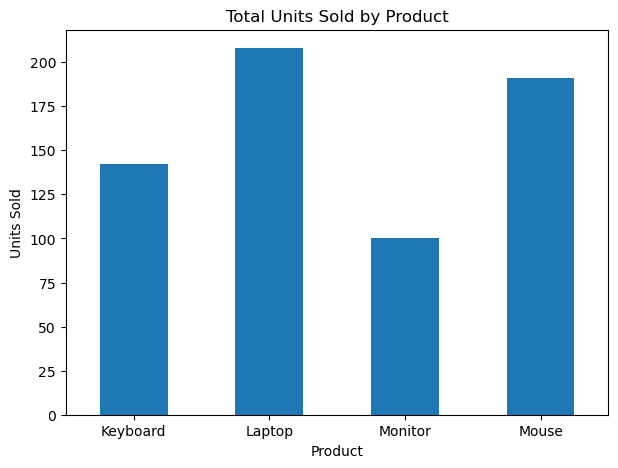

In [4]:
product_sales = df.groupby('Product')['Units_Sold'].sum()

plt.figure(figsize=(7, 5))
product_sales.plot(kind='bar')

plt.title('Total Units Sold by Product')
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.xticks(rotation=0)

plt.show()

### Bar Chart Observation

The bar chart compares the total number of units sold for each product. It shows that sales volume varies across the different products. The laptop total is also affected by one unusually high sales value in the dataset.

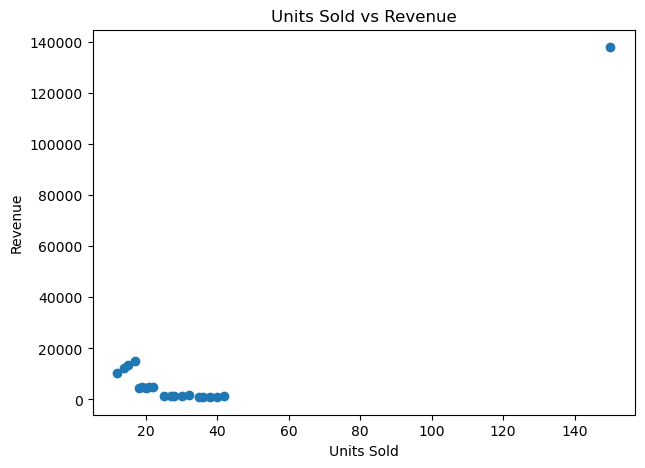

In [5]:
plt.figure(figsize=(7, 5))

plt.scatter(df['Units_Sold'], df['Revenue'])

plt.title('Units Sold vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue')

plt.show()

### Scatter Plot Observation

The scatter plot shows the relationship between Units_Sold and Revenue. Most of the points are grouped in the lower range, while one point is much higher than the others. This indicates an unusual observation in the dataset that may be an outlier.

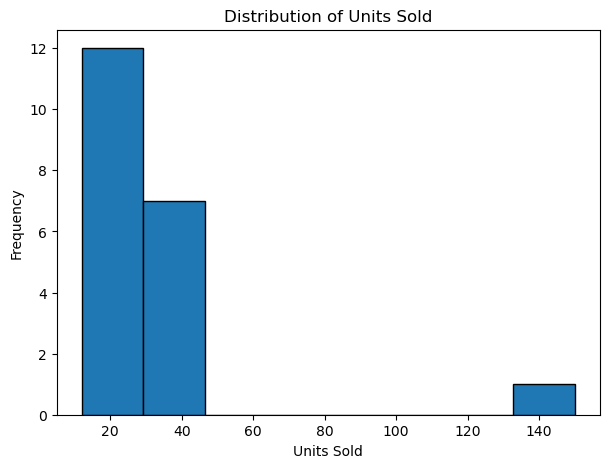

In [6]:
plt.figure(figsize=(7, 5))

plt.hist(df['Units_Sold'], bins=8, edgecolor='black')

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.show()

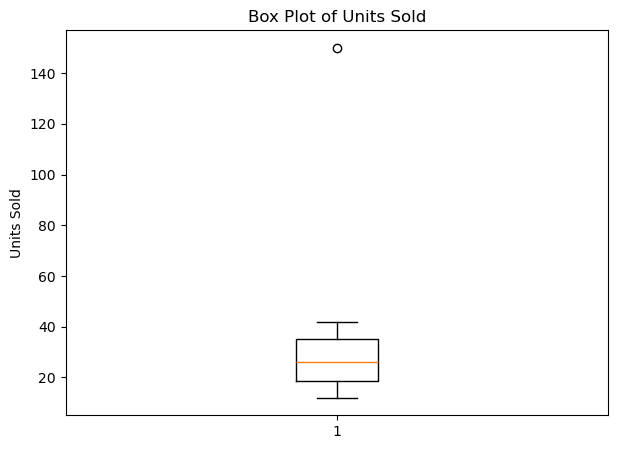

In [7]:
plt.figure(figsize=(7, 5))

plt.boxplot(df['Units_Sold'])

plt.title('Box Plot of Units Sold')
plt.ylabel('Units Sold')

plt.show()

In [8]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df[df.isnull().any(axis=1)]

Missing values before cleaning:
Date               0
Product            0
Category           0
Region             2
Units_Sold         0
Unit_Price         0
Customer_Rating    2
Revenue            0
dtype: int64


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
5,2026-02-09,Mouse,Accessories,West,42,30,NaN,1260
6,2026-02-16,Keyboard,Accessories,None,30,50,4.1,1500
13,2026-04-08,Mouse,Accessories,None,40,27,4.1,1080
14,2026-04-15,Keyboard,Accessories,South,32,52,NaN,1664


In [10]:
Q1 = df_clean['Units_Sold'].quantile(0.25)
Q3 = df_clean['Units_Sold'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 18.75
Q3: 35.25
IQR: 16.5
Lower Bound: -6.0
Upper Bound: 60.0


In [9]:
df_clean = df.copy()

df_clean['Customer_Rating'] = df_clean['Customer_Rating'].fillna(
    df_clean['Customer_Rating'].mean()
)

df_clean['Region'] = df_clean['Region'].fillna(
    df_clean['Region'].mode()[0]
)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

df_clean.head()

Missing values after cleaning:
Date               0
Product            0
Category           0
Region             0
Units_Sold         0
Unit_Price         0
Customer_Rating    0
Revenue            0
dtype: int64


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
0,2026-01-05,Laptop,Computers,East,12,850,4.5,10200
1,2026-01-12,Mouse,Accessories,West,35,25,4.0,875
2,2026-01-19,Keyboard,Accessories,South,28,45,4.2,1260
3,2026-01-26,Monitor,Electronics,North,20,220,3.9,4400
4,2026-02-02,Laptop,Computers,East,15,900,4.6,13500


### Handling Missing Values

I checked the dataset for missing values using `isnull().sum()`. The Region column had 2 missing values and the Customer_Rating column also had 2 missing values.

I replaced the missing Customer_Rating values with the mean because it is numerical. I replaced the missing Region values with the mode because Region is categorical. After cleaning, there were no missing values left in the dataset.

### Outlier Detection and Removal

I used the IQR method to identify unusual values in the Units_Sold column. The IQR was calculated using the first quartile (Q1) and third quartile (Q3).

Values outside the lower and upper bounds were treated as outliers. One high Units_Sold value was identified as an outlier and removed before continuing with the analysis.

In [11]:
outliers = df_clean[
    (df_clean['Units_Sold'] < lower_bound) |
    (df_clean['Units_Sold'] > upper_bound)
]

print("Identified Outliers:")
outliers

Identified Outliers:


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
12,2026-04-01,Laptop,Computers,East,150,920,4.5,138000


In [12]:
df_no_outliers = df_clean[
    (df_clean['Units_Sold'] >= lower_bound) &
    (df_clean['Units_Sold'] <= upper_bound)
].copy()

print("Original number of rows:", len(df_clean))
print("Rows after removing outliers:", len(df_no_outliers))

df_no_outliers.head()

Original number of rows: 20
Rows after removing outliers: 19


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
0,2026-01-05,Laptop,Computers,East,12,850,4.5,10200
1,2026-01-12,Mouse,Accessories,West,35,25,4.0,875
2,2026-01-19,Keyboard,Accessories,South,28,45,4.2,1260
3,2026-01-26,Monitor,Electronics,North,20,220,3.9,4400
4,2026-02-02,Laptop,Computers,East,15,900,4.6,13500


### Data Reduction

I reduced the dataset in two ways. First, I used random sampling to keep 70% of the cleaned data. I used `random_state=42` so that the same sample can be reproduced.

I also removed the Date column to demonstrate dimension reduction because it was not needed for the next numerical analysis steps.

In [13]:
print("Dataset before data reduction:")
print(df_no_outliers.shape)

df_no_outliers.head()

Dataset before data reduction:
(19, 8)


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
0,2026-01-05,Laptop,Computers,East,12,850,4.5,10200
1,2026-01-12,Mouse,Accessories,West,35,25,4.0,875
2,2026-01-19,Keyboard,Accessories,South,28,45,4.2,1260
3,2026-01-26,Monitor,Electronics,North,20,220,3.9,4400
4,2026-02-02,Laptop,Computers,East,15,900,4.6,13500


In [14]:
sample_df = df_no_outliers.sample(frac=0.70, random_state=42)

print("Dataset after 70% sampling:")
print(sample_df.shape)

sample_df.head()

Dataset after 70% sampling:
(13, 8)


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
0,2026-01-05,Laptop,Computers,East,12,850,4.500000,10200
5,2026-02-09,Mouse,Accessories,West,42,30,4.238889,1260
11,2026-03-23,Monitor,Electronics,North,22,230,4.200000,5060
1,2026-01-12,Mouse,Accessories,West,35,25,4.000000,875
8,2026-03-02,Laptop,Computers,South,17,875,4.700000,14875


In [15]:
reduced_df = sample_df.drop(columns=['Date'])

print("Columns before dimension reduction:")
print(sample_df.columns.tolist())

print("\nColumns after dimension reduction:")
print(reduced_df.columns.tolist())

Columns before dimension reduction:
['Date', 'Product', 'Category', 'Region', 'Units_Sold', 'Unit_Price', 'Customer_Rating', 'Revenue']

Columns after dimension reduction:
['Product', 'Category', 'Region', 'Units_Sold', 'Unit_Price', 'Customer_Rating', 'Revenue']


### Data Scaling

I applied Min-Max scaling to the Units_Sold, Unit_Price, and Revenue columns. This method changes the values to a range between 0 and 1.

Scaling helps make numerical variables easier to compare when they have very different value ranges.

In [16]:
print("Before Min-Max Scaling:")

df_no_outliers[['Units_Sold', 'Unit_Price', 'Revenue']].head()

Before Min-Max Scaling:


,Units_Sold,Unit_Price,Revenue
0,12,850,10200
1,35,25,875
2,28,45,1260
3,20,220,4400
4,15,900,13500


In [17]:
scaled_df = df_no_outliers.copy()

columns_to_scale = ['Units_Sold', 'Unit_Price', 'Revenue']

for column in columns_to_scale:
    min_value = scaled_df[column].min()
    max_value = scaled_df[column].max()

    scaled_df[column + '_Scaled'] = (
        (scaled_df[column] - min_value) /
        (max_value - min_value)
    )

scaled_df[
    ['Units_Sold', 'Units_Sold_Scaled',
     'Unit_Price', 'Unit_Price_Scaled',
     'Revenue', 'Revenue_Scaled']
].head()

,Units_Sold,Units_Sold_Scaled,Unit_Price,Unit_Price_Scaled,Revenue,Revenue_Scaled
0,12,0.000000,850,0.942857,10200,0.666071
1,35,0.766667,25,0.000000,875,0.000000
2,28,0.533333,45,0.022857,1260,0.027500
3,20,0.266667,220,0.222857,4400,0.251786
4,15,0.100000,900,1.000000,13500,0.901786


### Discretization

I converted the Customer_Rating values into categories called Average, Good, and Excellent.

This makes the numerical rating values easier to understand and compare by grouping them into meaningful categories.

In [18]:
df_no_outliers['Rating_Category'] = pd.cut(
    df_no_outliers['Customer_Rating'],
    bins=[0, 4.0, 4.4, 5.0],
    labels=['Average', 'Good', 'Excellent'],
    include_lowest=True
)

df_no_outliers[
    ['Customer_Rating', 'Rating_Category']
].head(10)

,Customer_Rating,Rating_Category
0,4.500000,Excellent
1,4.000000,Average
2,4.200000,Good
3,3.900000,Average
4,4.600000,Excellent
5,4.238889,Good
6,4.100000,Good
7,4.300000,Good
8,4.700000,Excellent
9,3.800000,Average


## Statistical Analysis

### General Overview of Data

I used `info()` and `describe()` to understand the structure of the cleaned dataset. These functions show the number of rows, column data types, non-null values, and basic descriptive statistics.

In [19]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 19
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             19 non-null     datetime64[ns]
 1   Product          19 non-null     object        
 2   Category         19 non-null     object        
 3   Region           19 non-null     object        
 4   Units_Sold       19 non-null     int64         
 5   Unit_Price       19 non-null     int64         
 6   Customer_Rating  19 non-null     float64       
 7   Revenue          19 non-null     int64         
 8   Rating_Category  19 non-null     category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 1.5+ KB


In [20]:
df_no_outliers.describe()

,Date,Units_Sold,Unit_Price,Customer_Rating,Revenue
count,19,19.000000,19.000000,19.000000,19.000000
mean,2026-03-12 17:41:03.157894656,25.842105,266.894737,4.225146,4564.000000
min,2026-01-05 00:00:00,12.000000,25.000000,3.800000,875.000000
25%,2026-02-05 12:00:00,18.500000,37.500000,4.050000,1230.000000
50%,2026-03-09 00:00:00,25.000000,52.000000,4.200000,1664.000000
75%,2026-04-18 12:00:00,33.500000,245.000000,4.350000,4997.500000
max,2026-05-22 00:00:00,42.000000,900.000000,4.700000,14875.000000
std,NaN,9.328946,335.745256,0.252874,4672.476384


### Central Tendency Measures

I calculated the minimum, maximum, mean, median, and mode for the Units_Sold column.

These measures help summarize the typical sales values and show the center of the data.

In [21]:
minimum = df_no_outliers['Units_Sold'].min()
maximum = df_no_outliers['Units_Sold'].max()
mean = df_no_outliers['Units_Sold'].mean()
median = df_no_outliers['Units_Sold'].median()
mode = df_no_outliers['Units_Sold'].mode().tolist()

print("Units Sold Statistics")
print("---------------------")
print("Minimum:", minimum)
print("Maximum:", maximum)
print("Mean:", round(mean, 2))
print("Median:", median)
print("Mode:", mode)

Units Sold Statistics
---------------------
Minimum: 12
Maximum: 42
Mean: 25.84
Median: 25.0
Mode: [12, 14, 15, 17, 18, 19, 20, 21, 22, 25, 27, 28, 30, 32, 35, 36, 38, 40, 42]


### Dispersion Measures

I calculated the range, quartiles, IQR, variance, and standard deviation for the Units_Sold column.

These measures help show how spread out the sales values are and how much the values differ from the average.

In [22]:
sales_range = (
    df_no_outliers['Units_Sold'].max() -
    df_no_outliers['Units_Sold'].min()
)

Q1 = df_no_outliers['Units_Sold'].quantile(0.25)
Q2 = df_no_outliers['Units_Sold'].quantile(0.50)
Q3 = df_no_outliers['Units_Sold'].quantile(0.75)

IQR = Q3 - Q1

variance = df_no_outliers['Units_Sold'].var()
std_dev = df_no_outliers['Units_Sold'].std()

print("Dispersion Measures for Units Sold")
print("----------------------------------")
print("Range:", sales_range)
print("Q1:", Q1)
print("Q2 (Median):", Q2)
print("Q3:", Q3)
print("IQR:", IQR)
print("Variance:", round(variance, 2))
print("Standard Deviation:", round(std_dev, 2))

Dispersion Measures for Units Sold
----------------------------------
Range: 30
Q1: 18.5
Q2 (Median): 25.0
Q3: 33.5
IQR: 15.0
Variance: 87.03
Standard Deviation: 9.33


In [25]:
numeric_columns = [
    'Units_Sold',
    'Unit_Price',
    'Customer_Rating',
    'Revenue'
]

correlation_matrix = df_no_outliers[numeric_columns].corr()

correlation_matrix.round(2)

,Units_Sold,Unit_Price,Customer_Rating,Revenue
Units_Sold,1.00,-0.79,-0.67,-0.78
Unit_Price,-0.79,1.00,0.82,0.98
Customer_Rating,-0.67,0.82,1.00,0.83
Revenue,-0.78,0.98,0.83,1.00


### Correlation Analysis

The correlation matrix shows the relationship between the numerical variables in the dataset. Values closer to 1 indicate a strong positive relationship, while values closer to -1 indicate a strong negative relationship.

In this dataset, Revenue has a strong positive correlation with Unit_Price. Customer_Rating also shows a positive relationship with Revenue. Units_Sold shows a negative correlation with Revenue in the cleaned dataset, which may be influenced by the different prices of the products.

## Conclusion

This lab helped me understand how to work with data using Python and Jupyter Notebook. I created and explored a retail sales dataset using different visualizations and statistical techniques.

I handled missing values using mean and mode replacement, detected and removed an outlier using the IQR method, reduced the dataset using sampling and column removal, and applied Min-Max scaling and discretization.

I also used descriptive statistics, central tendency measures, dispersion measures, and correlation analysis to better understand the dataset. Overall, this lab gave me practical experience with data preprocessing and basic data analysis.